First 5 rows of dataset:
   Temperature    Voltage  Signal_Strength
0    52.483571  26.584629        76.431149
1    49.308678  27.579355        77.243138
2    53.238443  27.657285        79.332205
3    57.615149  27.197723        79.215208
4    48.829233  27.838714        69.489323

Dataset Shape: (115, 3)

Anomaly Count:
Anomaly
0    92
1    23
Name: count, dtype: int64


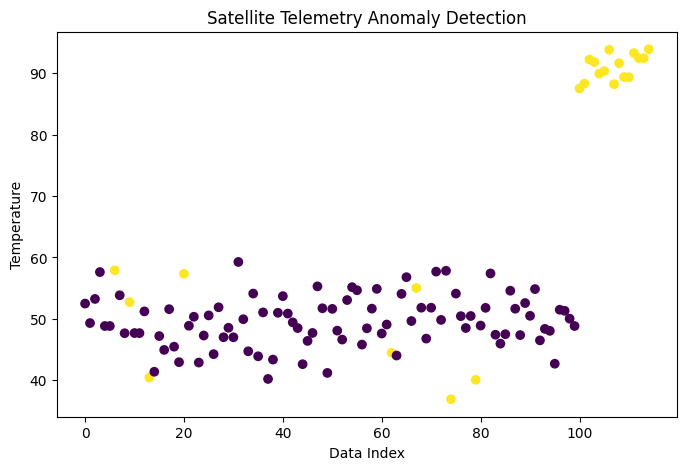

In [5]:
# ===============================
# Satellite Telemetry Anomaly Detection
# ===============================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# -------------------------------
# Step 1: Load Dataset
# -------------------------------

data = pd.read_excel("satellite_telemetry.csv")

print("First 5 rows of dataset:")
print(data.head())

print("\nDataset Shape:", data.shape)

# -------------------------------
# Step 2: Apply Isolation Forest
# -------------------------------

model = IsolationForest(contamination=0.2, random_state=42)

model.fit(data)

data["Anomaly"] = model.predict(data)

# Convert prediction values
# 1 = Normal
# -1 = Anomaly

data["Anomaly"] = data["Anomaly"].map({1:0, -1:1})

print("\nAnomaly Count:")
print(data["Anomaly"].value_counts())

# -------------------------------
# Step 3: Visualization
# -------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    data.index,
    data["Temperature"],
    c=data["Anomaly"]
)

plt.xlabel("Data Index")
plt.ylabel("Temperature")
plt.title("Satellite Telemetry Anomaly Detection")

plt.show()